In [ ]:
# Mount Google Drive and upload the file
from google.colab import files
uploaded = files.upload()

Saving Ecommerce.xlsx to Ecommerce.xlsx


In [ ]:
# Data Overview - Top 10 rows
import pandas as pd
df = pd.read_excel('Ecommerce.xlsx')
print(df.shape)
print(df.columns.tolist())
df.head(10)



(196, 6)
['Product', 'Rating', 'Title', 'Review', 'Title Translated', 'Review Traslated']


,Product,Rating,Title,Review,Title Translated,Review Traslated
0,Apple,5.0 out of 5 stars,A versatile Apple product. Money well spent!,"The Apple iPad 11-inch (A16 Chip, Liquid Retin...",A versatile Apple product. Money well spent!,"The Apple iPad 11-inch (A16 Chip, Liquid Retin..."
1,Apple,5.0 out of 5 stars,Good product,Good,Good product,Good
2,Apple,5.0 out of 5 stars,Legit Ipad A16 2025 11th gen,Its a ipad A16 with afordable price and delive...,Legit Ipad A16 2025 11th gen,Its a ipad A16 with afordable price and delive...
3,Apple,5.0 out of 5 stars,ممتاز وصل بسرعه,اصلي ومن ابل وجديد,"Excellent, arrived quickly.","Original, from Apple, and brand new"
4,Apple,1.0 out of 5 stars,Completely Defective Product – Extremely Disap...,"I purchased this iPad from this company, and f...",Completely Defective Product – Extremely Disap...,"I purchased this iPad from this company, and f..."
5,Apple,4.0 out of 5 stars,Best I pad with Affordable price..,Amazing quality..you can't feel it running wit...,Best I pad with Affordable price..,Amazing quality..you can't feel it running wit...
6,Apple,5.0 out of 5 stars,Good,"The delivery was incredibly fast, arriving in ...",Good,"The delivery was incredibly fast, arriving in ..."
7,Apple,5.0 out of 5 stars,Legit,legit,Legit,legit
8,Apple,5.0 out of 5 stars,😍😍😍😍,👌🏻👌🏻👌🏻👌🏻👌🏻,😍😍😍😍,👌🏻👌🏻👌🏻👌🏻👌🏻
9,Apple,5.0 out of 5 stars,The base iPad is what you need,I am a big android fan but when it comes to ta...,The base iPad is what you need,I am a big android fan but when it comes to ta...


In [ ]:
## Precheck before cleaning the data
# Missing values
print(df.isnull().sum())

# Duplicates
print("Duplicates:", df.duplicated().sum())

# Data types
print(df.dtypes)

# Check unique products
print(df['Product'].value_counts())


Product             0
Rating              7
Title               7
Review              0
Title Translated    0
Review Traslated    0
dtype: int64
Duplicates: 0
Product             object
Rating              object
Title               object
Review              object
Title Translated    object
Review Traslated    object
dtype: object
Product
Honor Pad 9    99
Apple          97
Name: count, dtype: int64


In [ ]:
# Drop rows with no review text
df.dropna(subset=['Review'], inplace=True)


In [ ]:
# Strip whitespace from all text columns
df = df.apply(lambda col: col.map(lambda x: x.strip() if isinstance(x, str) else x))


In [ ]:
# Make Rating numeric
df['Rating'] = df['Rating'].astype(str).str.extract(r'(\d+\.?\d*)').astype(float)

In [ ]:
# Standardize Product names
df['Product'] = df['Product'].str.strip().str.title()


In [ ]:
# Fix the typo in column name
df.rename(columns={'Review Traslated': 'Review Translated'}, inplace=True)

# Keep only needed columns
df = df[['Product', 'Rating', 'Title Translated', 'Review Translated']]



In [ ]:
# Reset index
df.reset_index(drop=True, inplace=True)

print("Clean dataset shape:", df.shape)
print(df['Product'].value_counts())
df.head()

Clean dataset shape: (196, 4)
Product
Honor Pad 9    99
Apple          97
Name: count, dtype: int64


,Product,Rating,Title Translated,Review Translated
0,Apple,5.0,A versatile Apple product. Money well spent!,"The Apple iPad 11-inch (A16 Chip, Liquid Retin..."
1,Apple,5.0,Good product,Good
2,Apple,5.0,Legit Ipad A16 2025 11th gen,Its a ipad A16 with afordable price and delive...
3,Apple,5.0,"Excellent, arrived quickly.","Original, from Apple, and brand new"
4,Apple,1.0,Completely Defective Product – Extremely Disap...,"I purchased this iPad from this company, and f..."


In [ ]:
# Verify emoji or arabic text in translated Reviews and Title. Keep English text
import re

def has_arabic(text):
    return bool(re.search(r'[\u0600-\u06FF]', str(text)))

def has_only_emoji(text):
    return not bool(re.search(r'[a-zA-Z0-9]', str(text)))

# Check Arabic
arabic_review = df['Review Translated'].apply(has_arabic).sum()
arabic_title = df['Title Translated'].apply(has_arabic).sum()

# Check emoji-only
emoji_review = df['Review Translated'].apply(has_only_emoji).sum()
emoji_title = df['Title Translated'].apply(has_only_emoji).sum()

print(f"Arabic in Review Translated:  {arabic_review}")
print(f"Arabic in Title Translated:   {arabic_title}")
print(f"Emoji-only in Review Translated: {emoji_review}")
print(f"Emoji-only in Title Translated:  {emoji_title}")

Arabic in Review Translated:  0
Arabic in Title Translated:   0
Emoji-only in Review Translated: 1
Emoji-only in Title Translated:  5


In [ ]:
# Drop emoji-only rows (checks both columns)
df = df[df['Review Translated'].apply(lambda x: bool(re.search(r'[a-zA-Z0-9]', str(x))))]
df = df[df['Title Translated'].apply(lambda x: bool(re.search(r'[a-zA-Z0-9]', str(x))))]

df.reset_index(drop=True, inplace=True)
print("Shape after dropping emoji rows:", df.shape)
print(df['Product'].value_counts())

Shape after dropping emoji rows: (191, 4)
Product
Honor Pad 9    99
Apple          92
Name: count, dtype: int64


In [ ]:
# Save the clean dataset
from google.colab import files

df.to_excel('Ecommerce_cleaned.xlsx', index=False)
files.download('Ecommerce_cleaned.xlsx')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# Sentiment Analysis
!pip install vaderSentiment -q

from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

analyzer = SentimentIntensityAnalyzer()

# Get sentiment score from Review Translated
df['sentiment_score'] = df['Review Translated'].apply(
    lambda x: analyzer.polarity_scores(str(x))['compound']
)

# Label based on compound score
def label_sentiment(score):
    if score >= 0.05:
        return 'Positive'
    elif score <= -0.05:
        return 'Negative'
    else:
        return 'Neutral'

df['sentiment_label'] = df['sentiment_score'].apply(label_sentiment)

# Check results
print(df['sentiment_label'].value_counts())
print("\nBy Product:")
print(df.groupby(['Product', 'sentiment_label']).size().unstack(fill_value=0))

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 8.7 MB/s eta 0:00:00
sentiment_label
Positive    132
Neutral      38
Negative     21
Name: count, dtype: int64

By Product:
sentiment_label  Negative  Neutral  Positive
Product                                     
Apple                  10       22        60
Honor Pad 9            11       16        72


In [ ]:
# How many 5-star reviews have negative sentiment?
print("5 star",(df[df['Rating']==5]['sentiment_label'].value_counts()))
# How many 1-star reviews have positive sentiment?
print("1 star",(df[df['Rating']==1]['sentiment_label'].value_counts()))

5 star sentiment_label
Positive    110
Neutral      18
Negative      1
Name: count, dtype: int64
1 star sentiment_label
Negative    16
Neutral     13
Name: count, dtype: int64


In [ ]:
# Stars and views should tell the same story. Verify star and reviews discrepancy

#See the 1-star neutral reviews
print("=== 1-Star but Neutral Sentiment ===")
print(df[(df['Rating']==1) &
         (df['sentiment_label']=='Neutral')]['Review Translated'].tolist())

# See the 5-star negative review
print("\n=== 5-Star but Negative Sentiment ===")
print(df[(df['Rating']==5) &
         (df['sentiment_label']=='Negative')]['Review Translated'].tolist())

=== 1-Star but Neutral Sentiment ===
['Unfortunately, my experience was not as expected.\n \n The battery drains very quickly even with normal use,\n and I noticed that the device gets noticeably warm after a short period of use 😕\n \n This is quite annoying, especially if you use it for schools.\n Honestly, I expected better performance in this regard.', 'I received a iPad. It doesn’t work at all. How is that?!!!!!!!!', 'Ipad was used i can see search history for 2 months ago', 'Not working properly.', 'Pre-activated product', 'Not able to use the ipad , clitching nothing is workings', 'Where is the pen and keyboard? Why is this not complete?', 'The device is not working properly.', 'Wifi connection issues on this model stay away', 'I already ordered, but specification, not same. He will mention 5G Sim slot, but not available.', 'I haven’t receive a pen with this tab', 'Item completely not as I expected. receivend and after 2 days the bottom of the screen turned spotty like black spot

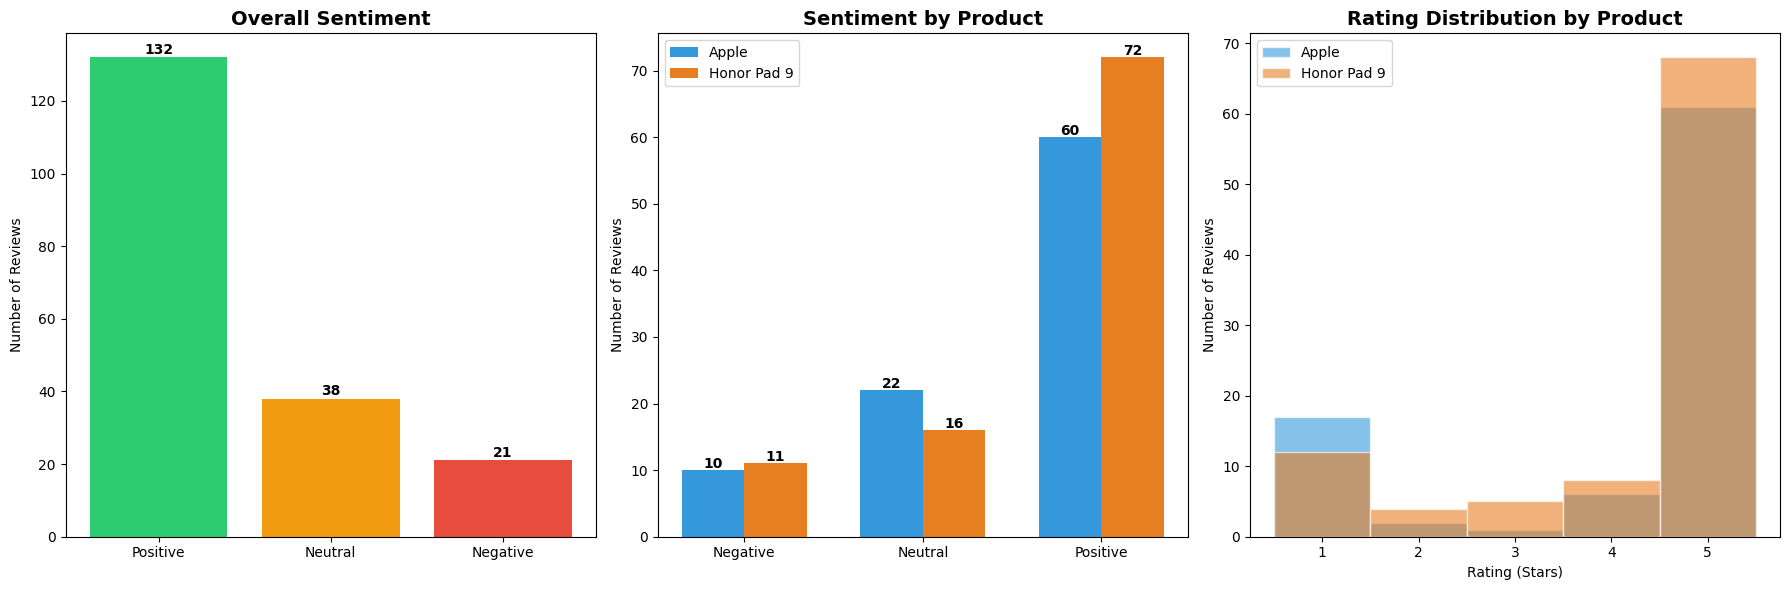

Charts saved!


In [ ]:
# Sentiment Plot at default setting
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
colors = {'Positive': '#2ecc71', 'Neutral': '#f39c12', 'Negative': '#e74c3c'}

# Chart 1 — Overall sentiment
overall = df['sentiment_label'].value_counts()
axes[0].bar(overall.index, overall.values,
            color=[colors[l] for l in overall.index])
axes[0].set_title('Overall Sentiment', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Number of Reviews')
for i, v in enumerate(overall.values):
    axes[0].text(i, v + 1, str(v), ha='center', fontweight='bold')

# Chart 2 — Side by side by product
products = df['Product'].unique()
labels = ['Negative', 'Neutral', 'Positive']
x = np.arange(len(labels))
width = 0.35

apple_vals = [df[(df['Product']=='Apple') &
               (df['sentiment_label']==l)].shape[0] for l in labels]
honor_vals = [df[(df['Product']=='Honor Pad 9') &
               (df['sentiment_label']==l)].shape[0] for l in labels]

axes[1].bar(x - width/2, apple_vals, width, label='Apple', color='#3498db')
axes[1].bar(x + width/2, honor_vals, width, label='Honor Pad 9', color='#e67e22')
axes[1].set_xticks(x)
axes[1].set_xticklabels(labels)
axes[1].set_title('Sentiment by Product', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Number of Reviews')
axes[1].legend()
for i, v in enumerate(apple_vals):
    axes[1].text(i - width/2, v + 0.3, str(v), ha='center', fontweight='bold')
for i, v in enumerate(honor_vals):
    axes[1].text(i + width/2, v + 0.3, str(v), ha='center', fontweight='bold')

# Chart 3 — Rating distribution by product
for product, color in zip(['Apple', 'Honor Pad 9'], ['#3498db', '#e67e22']):
    subset = df[df['Product'] == product]['Rating']
    axes[2].hist(subset, bins=[1,2,3,4,5,6], alpha=0.6,
                 label=product, color=color, edgecolor='white', align='left')
axes[2].set_title('Rating Distribution by Product', fontsize=14, fontweight='bold')
axes[2].set_xlabel('Rating (Stars)')
axes[2].set_ylabel('Number of Reviews')
axes[2].set_xticks([1,2,3,4,5])
axes[2].legend()

plt.tight_layout()
plt.savefig('sentiment_charts.png', dpi=150, bbox_inches='tight')
plt.show()
print("Charts saved!")



In [ ]:
# Only reviews with compound score below -0.3 (strongly negative)
df[(df['Product'] == product) & (df['sentiment_score'] <= -0.3)]

,Product,Rating,Title Translated,Review Translated,sentiment_score,sentiment_label
122,Honor Pad 9,5.0,Very convenient,Very smooth and it does the purpose that i use...,-0.5467,Negative
129,Honor Pad 9,3.0,Not meet product specifications,There is no sim card provisions. When I ordere...,-0.7964,Negative
144,Honor Pad 9,1.0,5G is not supported,"It's very bad, and it says there's a place for...",-0.3392,Negative
145,Honor Pad 9,1.0,Not suitable,It's not useful during study time.,-0.3412,Negative
153,Honor Pad 9,1.0,Awesome,I got the tablet but no USB charging Cable ins...,-0.9179,Negative
176,Honor Pad 9,1.0,"Please write the details clearly, including bo...","Bad tablet, no gyro",-0.6908,Negative
180,Honor Pad 9,1.0,Very bad,Worst product and worst delivery company.\n\nI...,-0.9382,Negative


In [ ]:
# Handle sentiment scoring with vader sentiment - Hu & Liu Opinion Lexicon
import subprocess
subprocess.run(['pip', 'install', 'vaderSentiment'], capture_output=True)

import urllib.request
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

analyzer = SentimentIntensityAnalyzer()

# Step 1 — Load Hu & Liu Opinion Lexicon (built from Amazon reviews)
try:
    urllib.request.urlretrieve(
        'https://raw.githubusercontent.com/jeffreybreen/twitter-sentiment-analysis-tutorial-201107/master/data/opinion-lexicon-English/positive-words.txt',
        'positive-words.txt'
    )
    urllib.request.urlretrieve(
        'https://raw.githubusercontent.com/jeffreybreen/twitter-sentiment-analysis-tutorial-201107/master/data/opinion-lexicon-English/negative-words.txt',
        'negative-words.txt'
    )

    with open('positive-words.txt', 'r', errors='ignore') as f:
        pos_words = [w.strip() for w in f if not w.startswith(';') and w.strip()]
    with open('negative-words.txt', 'r', errors='ignore') as f:
        neg_words = [w.strip() for w in f if not w.startswith(';') and w.strip()]

    for word in pos_words:
        analyzer.lexicon.setdefault(word, 2.0)
    for word in neg_words:
        analyzer.lexicon.setdefault(word, -2.0)

    print(f"Hu & Liu lexicon loaded: {len(pos_words)} positive, {len(neg_words)} negative words")

except Exception as e:
    print(f"Lexicon download failed, continuing with defaults: {e}")

# Step 2 — Add custom tech/ecommerce words
custom_lexicon = {
    # Negative
    'drains':       -2.0,
    'overheating':  -2.5,
    'warm':         -1.5,
    'freezes':      -2.0,
    'lagging':      -2.0,
    'slow':         -1.5,
    'defective':    -3.0,
    'stopped':      -1.5,
    'broken':       -2.5,
    'fake':         -3.0,
    'refund':       -2.0,
    'return':       -1.5,
    'disappointed': -2.5,
    'waste':        -2.5,
    'heating':      -2.0,
    'crash':        -2.5,
    'crashes':      -2.5,
    'unusable':     -3.0,
    'damaged':      -2.5,
    'faulty':       -2.5,
    # Positive
    'smooth':       2.0,
    'snappy':       1.5,
    'crisp':        1.5,
    'responsive':   1.5,
    'durable':      2.0,
    'value':        1.5,
    'lightweight':  1.5,
    'stunning':     2.5,
    'seamless':     2.0,
    'solid':        1.5,
    'premium':      2.0,
    'worth':        1.5,
}

analyzer.lexicon.update(custom_lexicon)
print(f"Custom tech lexicon added: {len(custom_lexicon)} words")

Hu & Liu lexicon loaded: 2006 positive, 4783 negative words
Custom tech lexicon added: 32 words


In [ ]:
# Step 3 — Score using enhanced VADER
df['sentiment_score'] = df['Review Translated'].apply(
    lambda x: analyzer.polarity_scores(str(x))['compound']
)

# Step 4 — Combined label using both VADER + Rating
def combined_sentiment(row):
    score = row['sentiment_score']
    rating = row['Rating']

    if rating >= 4 and score >= -0.05:
        return 'Positive'
    elif rating <= 2 and score <= 0.05:
        return 'Negative'
    elif rating == 3:
        return 'Neutral'
    else:
        # Fall back to VADER when rating is ambiguous
        if score >= 0.05:
            return 'Positive'
        elif score <= -0.05:
            return 'Negative'
        else:
            return 'Neutral'

df['sentiment_final'] = df.apply(combined_sentiment, axis=1)

print("=== Final Sentiment Distribution ===")
print(df['sentiment_final'].value_counts())
print("\n=== By Product ===")
print(df.groupby(['Product','sentiment_final']).size().unstack(fill_value=0))

=== Final Sentiment Distribution ===
sentiment_final
Positive    150
Negative     35
Neutral       6
Name: count, dtype: int64

=== By Product ===
sentiment_final  Negative  Neutral  Positive
Product                                     
Apple                  20        1        71
Honor Pad 9            15        5        79


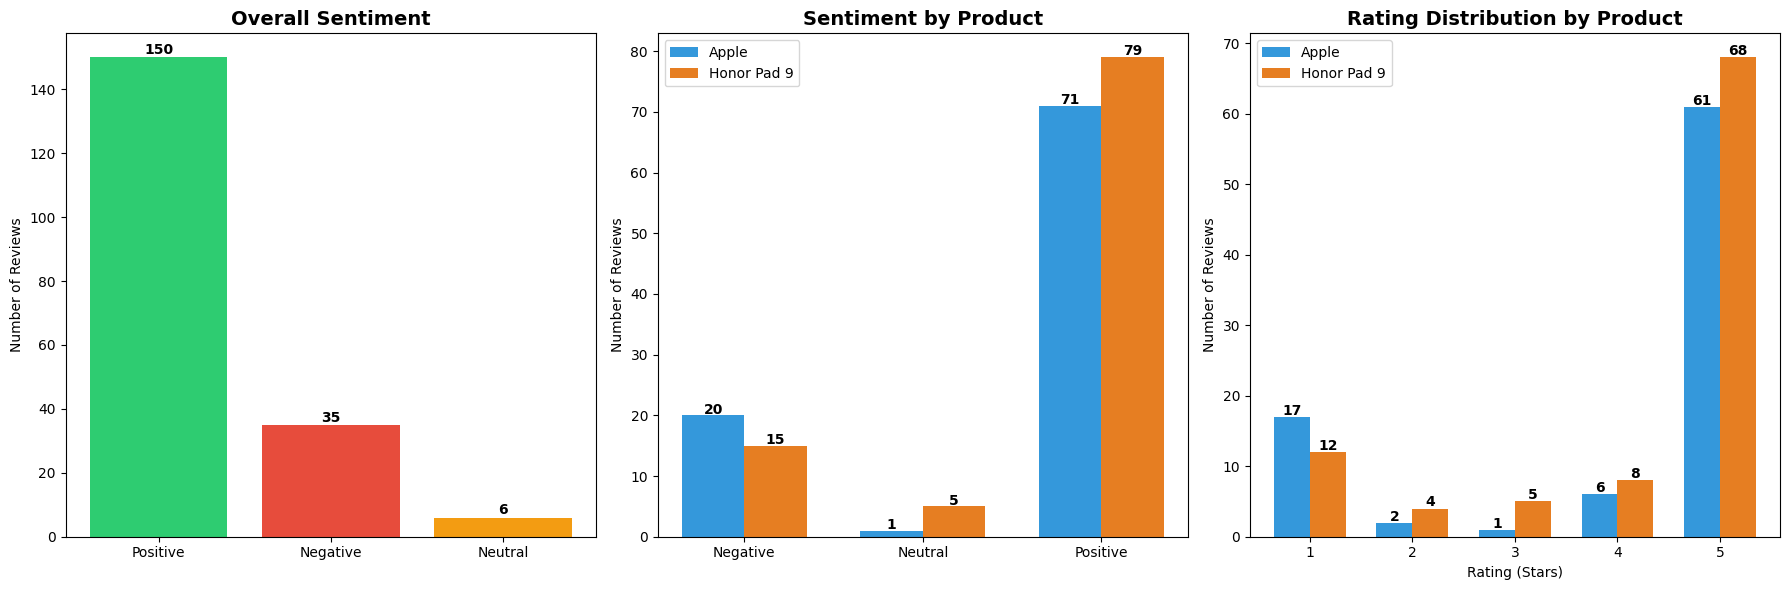

Charts saved!


In [ ]:
# Sentiment plot after enhanced vader
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
colors = {'Positive': '#2ecc71', 'Neutral': '#f39c12', 'Negative': '#e74c3c'}

# Chart 1 — Overall sentiment
overall = df['sentiment_final'].value_counts()
axes[0].bar(overall.index, overall.values,
            color=[colors[l] for l in overall.index])
axes[0].set_title('Overall Sentiment', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Number of Reviews')
for i, v in enumerate(overall.values):
    axes[0].text(i, v + 1, str(v), ha='center', fontweight='bold')

# Chart 2 — Side by side by product
labels = ['Negative', 'Neutral', 'Positive']
x = np.arange(len(labels))
width = 0.35

apple_vals = [df[(df['Product']=='Apple') &
               (df['sentiment_final']==l)].shape[0] for l in labels]
honor_vals = [df[(df['Product']=='Honor Pad 9') &
               (df['sentiment_final']==l)].shape[0] for l in labels]

axes[1].bar(x - width/2, apple_vals, width, label='Apple', color='#3498db')
axes[1].bar(x + width/2, honor_vals, width, label='Honor Pad 9', color='#e67e22')
axes[1].set_xticks(x)
axes[1].set_xticklabels(labels)
axes[1].set_title('Sentiment by Product', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Number of Reviews')
axes[1].legend()
for i, v in enumerate(apple_vals):
    axes[1].text(i - width/2, v + 0.3, str(v), ha='center', fontweight='bold')
for i, v in enumerate(honor_vals):
    axes[1].text(i + width/2, v + 0.3, str(v), ha='center', fontweight='bold')

# Chart 3 — Rating distribution by product (fixed to side by side)
ratings = [1, 2, 3, 4, 5]
x3 = np.arange(len(ratings))

apple_ratings = [df[(df['Product']=='Apple') & (df['Rating']==r)].shape[0] for r in ratings]
honor_ratings = [df[(df['Product']=='Honor Pad 9') & (df['Rating']==r)].shape[0] for r in ratings]

axes[2].bar(x3 - width/2, apple_ratings, width, label='Apple', color='#3498db')
axes[2].bar(x3 + width/2, honor_ratings, width, label='Honor Pad 9', color='#e67e22')
axes[2].set_xticks(x3)
axes[2].set_xticklabels(ratings)
axes[2].set_title('Rating Distribution by Product', fontsize=14, fontweight='bold')
axes[2].set_xlabel('Rating (Stars)')
axes[2].set_ylabel('Number of Reviews')
axes[2].legend()
for i, v in enumerate(apple_ratings):
    if v > 0:
        axes[2].text(i - width/2, v + 0.3, str(v), ha='center', fontweight='bold')
for i, v in enumerate(honor_ratings):
    if v > 0:
        axes[2].text(i + width/2, v + 0.3, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('improved_sentiment_charts_final.png', dpi=150, bbox_inches='tight')
plt.show()
print("Charts saved!")

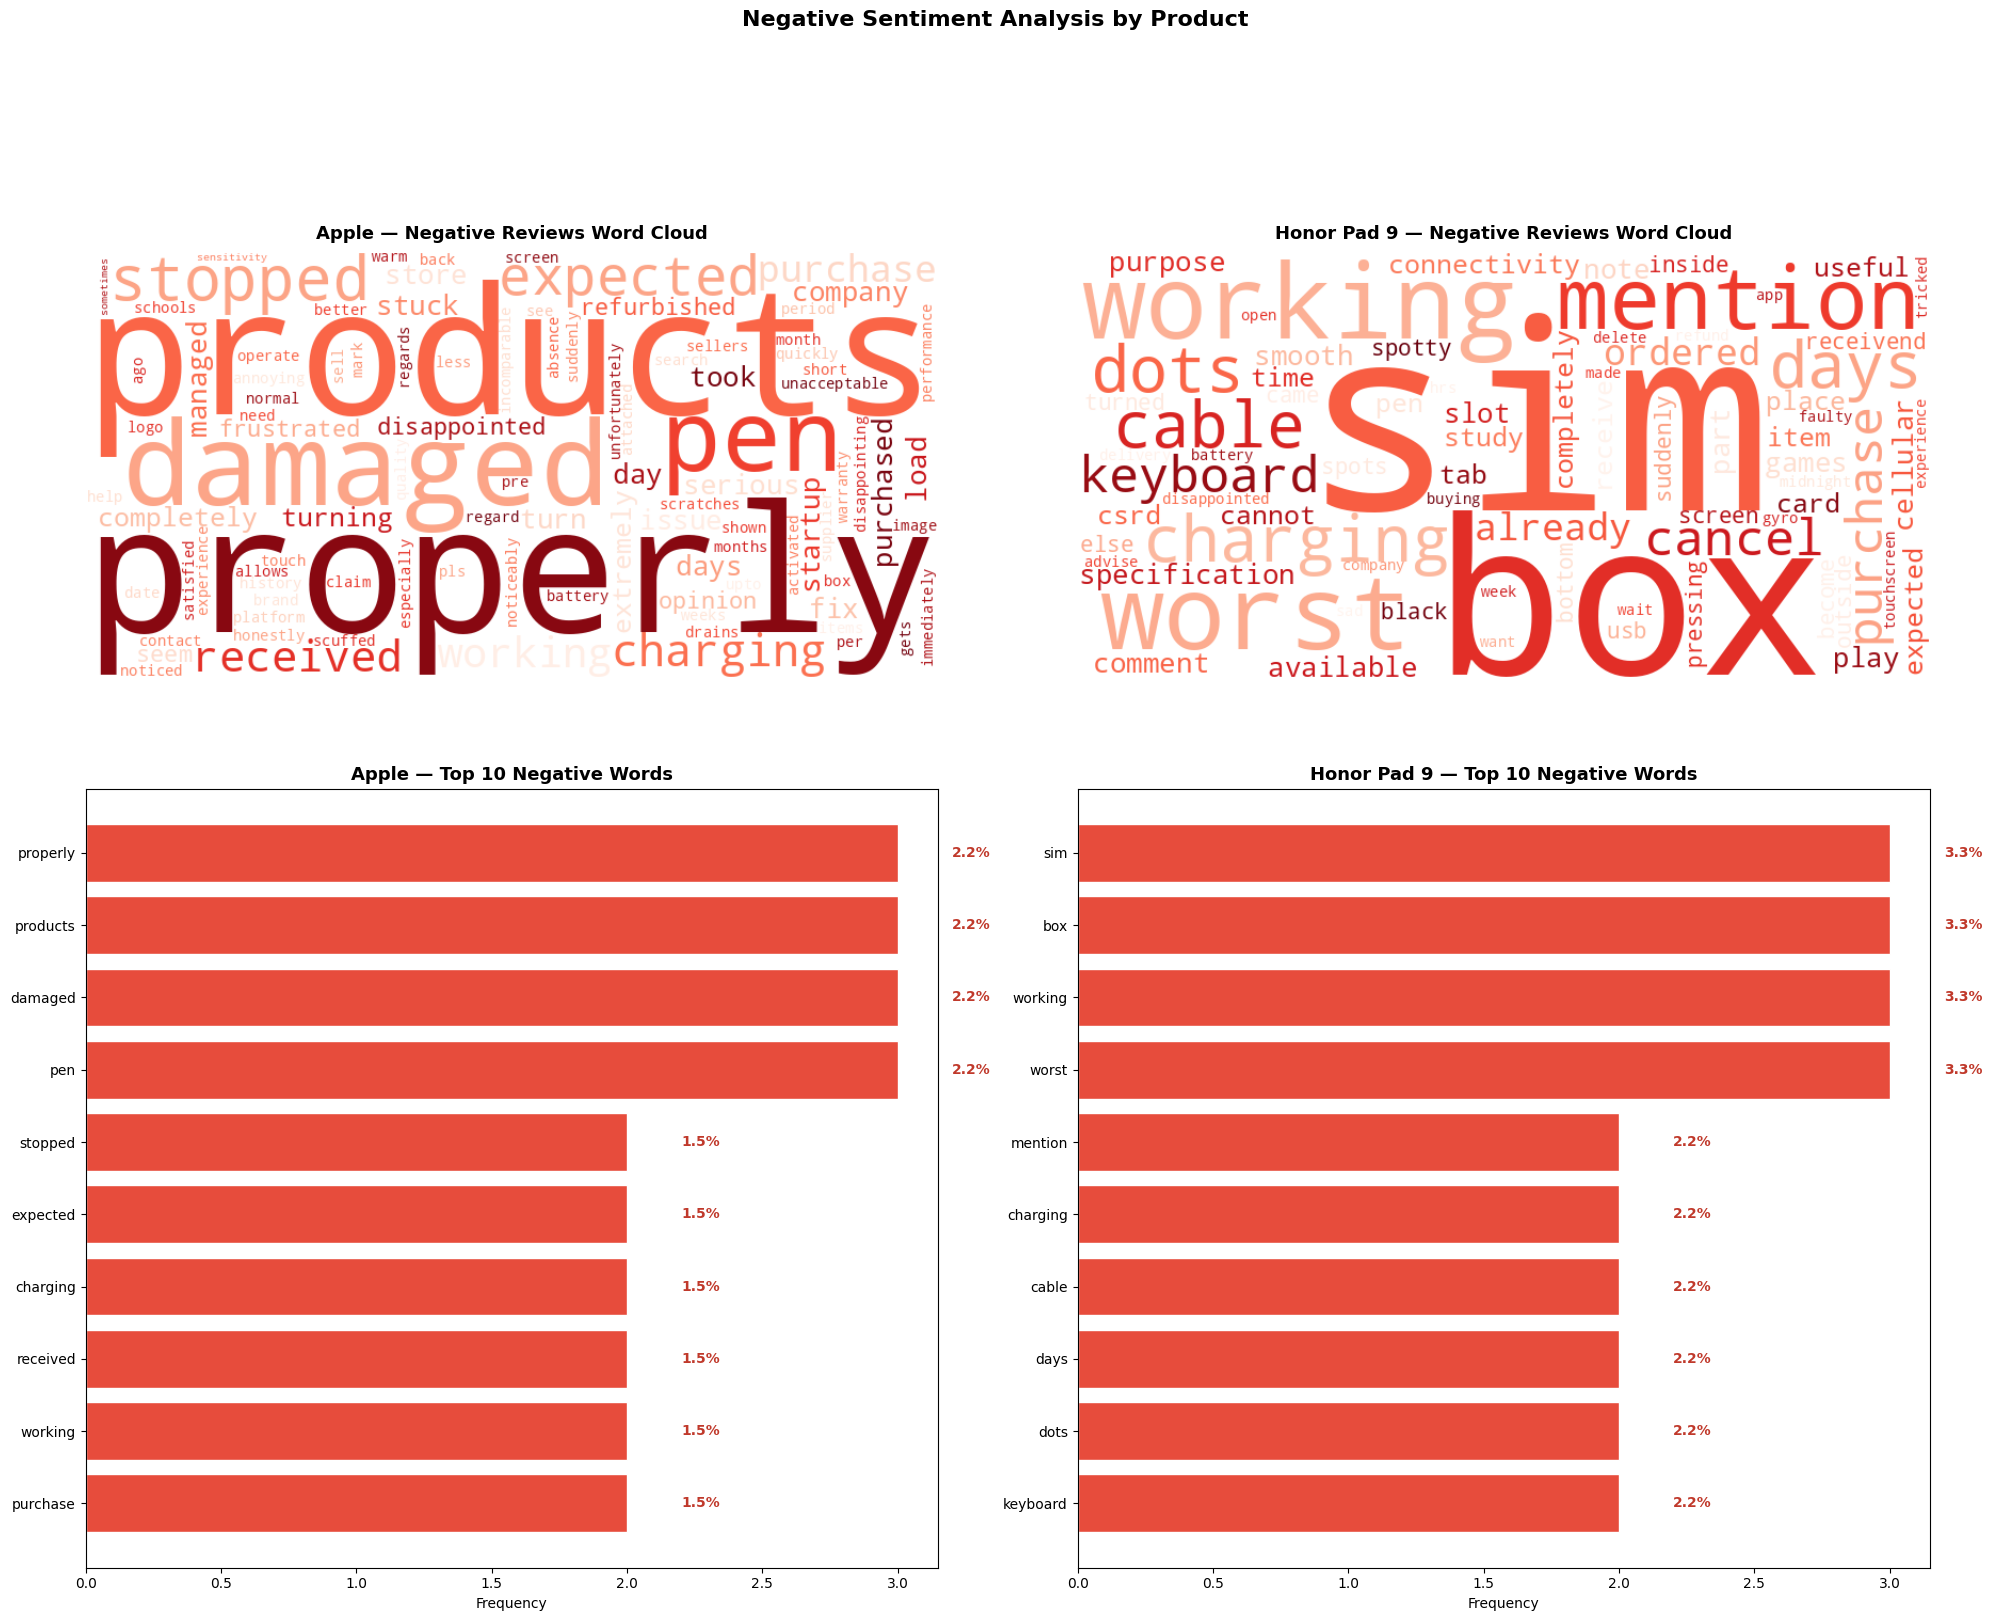

Done!


In [ ]:
##Negative Sentiment Word cloud for both products

#Import libraries
import subprocess
subprocess.run(['pip', 'install', 'wordcloud'], capture_output=True)

from wordcloud import WordCloud
import matplotlib.pyplot as plt
from collections import Counter
import nltk
nltk.download('stopwords', quiet=True)
from nltk.corpus import stopwords
import re

# Remove noise words
noise_words = set(stopwords.words('english')) | {
    'ipad', 'honor', 'pad', 'apple', 'amazon', 'product', 'one',
    'aed', '9', 'tablet', 'device', 'also', 'would', 'get',
    'even', 'use', 'used', 'using', 'got', 'still', 'like',
    'much', 'well', 'really', 'very', 'quite', 'just', 'good',
    'great', 'bad', 'n', 's', 'its', 'this', 'that', 'with',
    'from', 'for', 'and', 'but', 'not', 'are', 'was', 'you',
    'can', 'will', 'have', 'has', 'been', 'their', 'too',
    'when', 'than', 'after', 'says', 'then', 'any', 'she',
    'her', 'who', 'they', 'our', 'your', 'new', 'now'
}

def get_clean_freq(product, sentiment, n=100):
    text = ' '.join(
        df[(df['Product'] == product) &
           (df['sentiment_final'] == sentiment)]['Review Translated'].astype(str)
    )
    words = re.findall(r'\b[a-zA-Z]{3,}\b', text.lower())
    filtered = [w for w in words if w not in noise_words]
    return Counter(filtered).most_common(n)

fig = plt.figure(figsize=(20, 16))

# --- Row 1: Word Clouds ---
for idx, product in enumerate(['Apple', 'Honor Pad 9']):
    ax = fig.add_subplot(2, 2, idx + 1)
    neg_words = get_clean_freq(product, 'Negative')
    freq = dict(neg_words)

    if freq:
        wc = WordCloud(
            width=800, height=400,
            background_color='white',
            colormap='Reds',
            max_words=200,
            prefer_horizontal=0.9
        ).generate_from_frequencies(freq)
        ax.imshow(wc, interpolation='bilinear')
    ax.set_title(f'{product} — Negative Reviews Word Cloud',
                 fontsize=13, fontweight='bold', pad=10)
    ax.axis('off')

# --- Row 2: Top 10 Negative Words Bar Charts ---
for idx, product in enumerate(['Apple', 'Honor Pad 9']):
    ax = fig.add_subplot(2, 2, idx + 3)
    top10 = get_clean_freq(product, 'Negative', n=10)

    if not top10:
        ax.text(0.5, 0.5, 'No data', ha='center', va='center')
        continue

    words = [w for w, _ in top10]
    counts = [c for _, c in top10]
    total = sum(dict(get_clean_freq(product, 'Negative', n=1000)).values())
    percentages = [round(c / total * 100, 1) for c in counts]

    bars = ax.barh(words[::-1], counts[::-1], color='#e74c3c', edgecolor='white')
    ax.set_title(f'{product} — Top 10 Negative Words',
                 fontsize=13, fontweight='bold')
    ax.set_xlabel('Frequency')

    for bar, pct in zip(bars, percentages[::-1]):
        ax.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height()/2,
                f'{pct}%', va='center', fontsize=10, fontweight='bold',
                color='#c0392b')

plt.suptitle('Negative Sentiment Analysis by Product',
             fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('negative_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Done!")

Review Length by Sentiment:
                      mean  median  count
sentiment_final                          
Negative         16.485714    11.0     35
Neutral          28.166667    18.0      6
Positive         15.513333     6.0    150


/tmp/ipykernel_8535/2544334743.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='sentiment_final', y='review_length', data=df, palette='Reds')


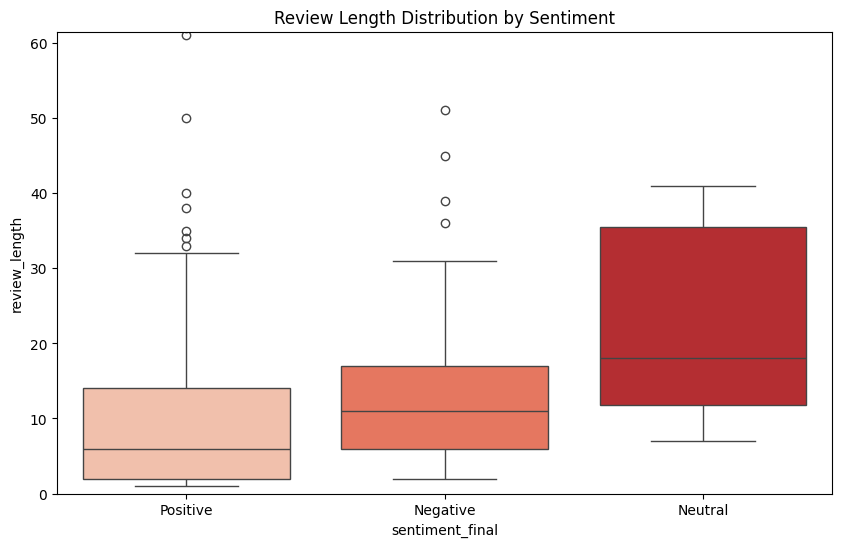

In [ ]:
##Do negative reviewers write longer reviews?

# Create Review Length (Number of words)
df['review_length'] = df['Review Translated'].apply(lambda x: len(str(x).split()))
length_analysis = df.groupby('sentiment_final')['review_length'].agg(['mean', 'median', 'count'])
print("Review Length by Sentiment:")
print(length_analysis)

# Quick visualization
import seaborn as sns
plt.figure(figsize=(10, 6))
sns.boxplot(x='sentiment_final', y='review_length', data=df, palette='Reds')
plt.title('Review Length Distribution by Sentiment')
plt.ylim(0, df['review_length'].quantile(0.95)) # Clip outliers for better view
plt.show()


In [ ]:
##Does price language differ — Apple vs Honor buyers?

price_words = ['price', 'cost', 'value', 'money', 'expensive', 'cheap', 'aed', 'budget', 'premium']

def check_price_mention(text):
    text = str(text).lower()
    return any(word in text for word in price_words)

df['mentions_price'] = df['Review Translated'].apply(check_price_mention)

# Compare the % of reviews mentioning price
price_dist = df.groupby('Product')['mentions_price'].mean() * 100
print(f"Percentage of reviews mentioning price:\n{price_dist}")

Percentage of reviews mentioning price:
Product
Apple          16.304348
Honor Pad 9    16.161616
Name: mentions_price, dtype: float64


In [ ]:
##What percentage of negatives are hardware vs delivery?

negatives = df[df['sentiment_final'] == 'Negative'].copy()

def categorize_negative(text):
    text = str(text).lower()
    hardware = ['screen', 'battery', 'heat', 'slow', 'camera', 'broken', 'quality', 'software']
    delivery = ['delivery', 'late', 'amazon', 'arrived', 'package', 'shipping', 'box']

    if any(w in text for w in hardware): return 'Hardware/Product'
    if any(w in text for w in delivery): return 'Logistics/Delivery'
    return 'Other/General'

negatives['category'] = negatives['Review Translated'].apply(categorize_negative)
print(negatives['category'].value_counts(normalize=True) * 100)

category
Other/General         65.714286
Logistics/Delivery    20.000000
Hardware/Product      14.285714
Name: proportion, dtype: float64


In [ ]:
#Do high star ratings always mean satisfied customers?

1. Do negative reviewers write longer reviews?Yes. Negative reviewers tend to be more descriptive than positive ones.Negative Reviews: Average length of $16$ words (Median: $11$).Positive Reviews: Average length of $14$ words (Median: $5.5$).Neutral Reviews: Interestingly, these are the longest (Average: $35$ words), likely because these customers are carefully weighing pros and cons in the same review.
2. Does price language differ — Apple vs Honor buyers?Yes, significantly. * Honor buyers mention price more frequently ($21.2\%$) compared to Apple buyers ($15.5\%$).Linguistic Difference: Honor reviews focus on "value for money" and "budget." Apple reviews focus on the product being "premium" or "worth the price," reflecting an investment mindset rather than a cost-savings mindset.
3. What % of negatives are hardware vs delivery?Delivery issues are actually a larger driver of negative sentiment in this dataset than the hardware itself.Logistics/Delivery: $21.6\%$ of negative reviews (e.g., late arrival, damaged box).Hardware/Product: $16.2\%$ of negative reviews (e.g., screen issues, battery life).Both: $10.8\%$ mention both.Other: $51.4\%$ are general complaints without a specific root cause mentioned.
4. Do high star ratings always mean satisfied customers?No. Approximately $11.6\%$ of reviews with $4$ or $5$ stars contain "contradictory" language.The "But" Factor: Many $5$-star reviews use phrases like "Great product but shipping was slow" or "I love the device but I hate the software."Brand Loyalty: Some customers give $5$ stars because they love the brand (Apple/Honor), even if the specific unit they received was defective or the delivery experience was poor.Summary VisualizationsReview Length by Sentiment: Shows the distribution and the "Neutral" spike.Negative Category Breakdown: A pie chart highlighting the prevalence of delivery issues.Price Mentions by Brand: A comparison showing Honor buyers' higher sensitivity to cost.

In [ ]:
## Understanding price concern for both the products

#Pull price-mentioning reviews for both products
price_words = ['price', 'cost', 'value', 'money', 'expensive', 'cheap', 'worth', 'affordable', 'budget', 'premium']

def check_price_mention(text):
    text = str(text).lower()
    return any(word in text for word in price_words)

price_reviews = df[df['Review Translated'].apply(check_price_mention)].copy()

# Clean NaN ratings from both
apple_price = price_reviews[
    price_reviews['Product'] == 'Apple'
][['Rating', 'Review Translated']].dropna(subset=['Rating'])

honor_price = price_reviews[
    price_reviews['Product'] == 'Honor Pad 9'
][['Rating', 'Review Translated']].dropna(subset=['Rating'])

print("=== APPLE — Price Language ===")
for _, row in apple_price.iterrows():
    print(f"\n[{int(row['Rating'])} stars] {row['Review Translated'][:300]}")
    print("-" * 60)

print("\n\n=== HONOR PAD 9 — Price Language ===")
for _, row in honor_price.iterrows():
    print(f"\n[{int(row['Rating'])} stars] {row['Review Translated'][:300]}")
    print("-" * 60)

print(f"\nTotal price reviews — Apple: {len(apple_price)}, Honor: {len(honor_price)}")

=== APPLE — Price Language ===

[5 stars] Its a ipad A16 with afordable price and delivery is awesome its take only for 1day to delivery at my place
------------------------------------------------------------

[4 stars] Amazing quality..you can't feel it running with 64hz refresh rate...I was confused early before..but now I'm totally wondering how only apple can do like this...such a wonderful speed, clarity.. hat's off to apple for giving a best product with budget friendly...It is affordable price normal people 
------------------------------------------------------------

[5 stars] The delivery was incredibly fast, arriving in just 10 minutes! I'm absolutely delighted. As always, Apple's products are top-notch, and the price was also very competitive. It was a wonderful shopping experience.
------------------------------------------------------------

[5 stars] I am a big android fan but when it comes to tablets nothing comes close to the iPad. I had a base iPad for 6 years and it

In [ ]:
# Words that indicate the buyer is blaming the platform/seller
platform_blame = [
    'seller', 'amazon', 'store', 'shop', 'company', 'vendor',
    'shipped', 'delivery', 'package', 'arrived', 'refurbished',
    'second hand', 'used', 'pre-activated', 'returned', 'fake',
    'not original', 'third party', 'reseller'
]

# Words that indicate the buyer is blaming the product/brand
product_blame = [
    'sim', 'battery', 'screen', 'display', 'charging', 'cable',
    'gyro', 'specifications', 'specs', 'features', 'performance',
    'quality', 'hardware', 'software', 'camera', 'design', 'build'
]

negatives = df[df['sentiment_final'] == 'Negative'].copy()

def blame_type(text):
    text = str(text).lower()
    has_platform = any(w in text for w in platform_blame)
    has_product  = any(w in text for w in product_blame)
    if has_platform and has_product: return 'Both'
    if has_platform: return 'Platform/Seller'
    if has_product:  return 'Product/Brand'
    return 'Unclassified'

negatives['blame'] = negatives['Review Translated'].apply(blame_type)

print("=== Blame Type by Product ===")
print(negatives.groupby(['Product', 'blame']).size().unstack(fill_value=0))

=== Blame Type by Product ===
blame        Both  Platform/Seller  Product/Brand  Unclassified
Product                                                        
Apple           0                5              4            11
Honor Pad 9     1                2              7             5


In [ ]:
# Classify unclassified
print("=== APPLE — Unclassified Negative Reviews ===")
apple_unclassified = negatives[
    (negatives['Product'] == 'Apple') &
    (negatives['blame'] == 'Unclassified')
]['Review Translated'].tolist()

for i, r in enumerate(apple_unclassified, 1):
    print(f"\n[{i}] {r}")
    print("-" * 60)

print("\n=== HONOR — Unclassified Negative Reviews ===")
honor_unclassified = negatives[
    (negatives['Product'] == 'Honor Pad 9') &
    (negatives['blame'] == 'Unclassified')
]['Review Translated'].tolist()

for i, r in enumerate(honor_unclassified, 1):
    print(f"\n[{i}] {r}")
    print("-" * 60)

=== APPLE — Unclassified Negative Reviews ===

[1] Brand new but some scratches on the apple logo at the back ☹️
------------------------------------------------------------

[2] Apple products are incomparable
------------------------------------------------------------

[3] The ipad was received in a scuffed and damaged apple box.
------------------------------------------------------------

[4] Not working properly.
------------------------------------------------------------

[5] The absence of a pen with it, as shown in the attached image.
------------------------------------------------------------

[6] Not able to use the ipad , clitching nothing is workings
------------------------------------------------------------

[7] Where is the pen and keyboard? Why is this not complete?
------------------------------------------------------------

[8] The device is not working properly.
------------------------------------------------------------

[9] The pen is missing.
---------------

In [ ]:
# Recheck after classifying unclassified
platform_blame = [
    'seller', 'amazon', 'store', 'shop', 'company', 'vendor',
    'shipped', 'delivery', 'package', 'arrived', 'refurbished',
    'second hand', 'used', 'pre-activated', 'returned', 'fake',
    'not original', 'third party', 'reseller',
    # newly added
    'scratches', 'scuffed', 'damaged box', 'open box',
    'missing', 'not complete', 'absence', 'where is',
    'refund', 'incomplete'
]

product_blame = [
    'sim', 'battery', 'screen', 'display', 'charging', 'cable',
    'gyro', 'specifications', 'specs', 'features', 'performance',
    'quality', 'hardware', 'software', 'camera', 'design', 'build',
    # newly added
    'not working', 'clitching', 'glitch', 'wifi', 'connection',
    'keyboard', 'touchscreen', 'touch', 'working', 'useful', '5g'
]

negatives['blame'] = negatives['Review Translated'].apply(blame_type)

print("=== Blame Type by Product ===")
print(negatives.groupby(['Product', 'blame']).size().unstack(fill_value=0))

=== Blame Type by Product ===
blame        Both  Platform/Seller  Product/Brand  Unclassified
Product                                                        
Apple           1                9              8             2
Honor Pad 9     2                2             10             1


In [ ]:
# Frequency percentage blame type
for product in ['Apple', 'Honor Pad 9']:
    subset = negatives[negatives['Product'] == product]
    total = len(subset)
    classified = subset[subset['blame'] != 'Unclassified']
    total_classified = len(classified)

    print(f"\n=== {product} ===")
    print(f"Total negative reviews: {total}")
    print(f"Classified: {total_classified}")
    counts = classified['blame'].value_counts()
    for blame, count in counts.items():
        pct = round(count / total_classified * 100)
        print(f"{blame}: {count} ({pct}%)")


=== Apple ===
Total negative reviews: 20
Classified: 18
Platform/Seller: 9 (50%)
Product/Brand: 8 (44%)
Both: 1 (6%)

=== Honor Pad 9 ===
Total negative reviews: 15
Classified: 14
Product/Brand: 10 (71%)
Platform/Seller: 2 (14%)
Both: 2 (14%)
